# Hierarchical Clustering

In [148]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

olivetti_faces = fetch_olivetti_faces()
X = olivetti_faces.images
y = olivetti_faces.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=86)

#reshape
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 340
Test set size: 60


In [149]:
# perform pca on the training set for feature extraction
from sklearn.decomposition import PCA
import numpy as np

X_train_flattened = X_train.reshape(X_train.shape[0], -1)

pca = PCA(n_components=0.95)
pca.fit(X_train_flattened)

X_train_pca = pca.transform(X_train_flattened)
print(f"Number of components: {pca.n_components_}")

Number of components: 114


In [160]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

def evaluate_knn_with_pca(X_train, y_train, n_splits=5, n_neighbors=5):

    # Create a K-Fold cross-validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=86)

    # Define the classifier
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    # List to store accuracy for each fold
    accuracies = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val = X_train[train_index], X_train[val_index]
        y_train_fold, y_val = y_train[train_index], y_train[val_index]

        # Train the classifier
        knn.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        y_pred = knn.predict(X_val)

        # Calculate accuracy
        accuracy = accuracy_score(y_val, y_pred)
        accuracies.append(accuracy)

    # Calculate average accuracy across all folds
    average_accuracy = sum(accuracies) / len(accuracies)

    return knn, average_accuracy

In [161]:
classifier, average_accuracy = evaluate_knn_with_pca(X_train_pca, y_train)
print(f"Average accuracy: {average_accuracy}")
print(f"Test accuracy: {classifier.score(pca.transform(X_test), y_test)}")

Average accuracy: 0.7470588235294118
Test accuracy: 0.7333333333333333


In [152]:
from scipy.spatial.distance import pdist, squareform

def compute_cosine_distance_matrix(X):
    # cosine similarity = 1 - cosine distance
    cosine_similarities =  1 - pdist(X, metric='cosine')
    
    # Convert the pairwise distances into a square matrix
    distance_matrix = squareform(cosine_similarities)
    
    return distance_matrix

def compute_minkowski_distance_matrix(X, p=1):
    minkowski_distances = pdist(X, metric='minkowski', p=p)
    
    # Convert the pairwise distances into a square matrix
    distance_matrix = squareform(minkowski_distances)
    
    return distance_matrix

def compute_euclidean_distance_matrix(X):
    euclidean_distances = pdist(X, metric='euclidean')
    
    # Convert the pairwise distances into a square matrix
    distance_matrix = squareform(euclidean_distances)
    
    return distance_matrix

/var/folders/xf/p8_7zzjj28d39_21yn7qm2nr0000gn/T/ipykernel_96705/1133536594.py:10: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_euclidean = linkage(euclidean_distance_matrix, method='centroid')
/var/folders/xf/p8_7zzjj28d39_21yn7qm2nr0000gn/T/ipykernel_96705/1133536594.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_minkowski = linkage(minkowski_distance_matrix, method='average')


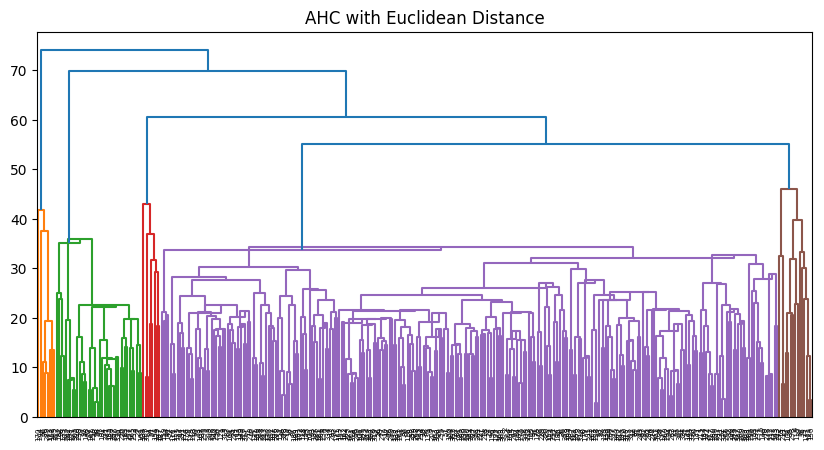

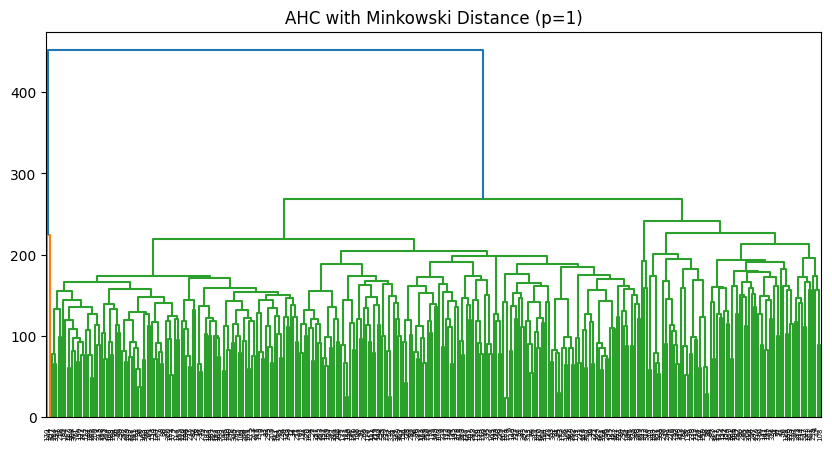

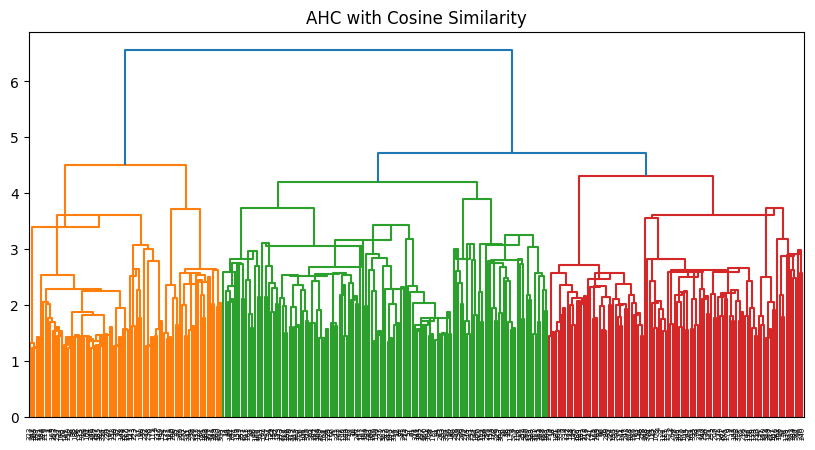

In [153]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


# Compute the distance matrices using the provided functions
euclidean_distance_matrix = compute_euclidean_distance_matrix(X_train_pca)
minkowski_distance_matrix = compute_minkowski_distance_matrix(X_train_pca)
cosine_distance_matrix = compute_cosine_distance_matrix(X_train_pca)

linkage_euclidean = linkage(euclidean_distance_matrix, method='centroid')
linkage_minkowski = linkage(minkowski_distance_matrix, method='average')
linkage_cosine = linkage(cosine_distance_matrix, method='centroid')

# Plot the dendrogram for Euclidean Distance
plt.figure(figsize=(10, 5))
dendrogram(linkage_euclidean)
plt.title('AHC with Euclidean Distance')
plt.show()

# Plot the dendrogram for Minkowski Distance (p=1)
plt.figure(figsize=(10, 5))
dendrogram(linkage_minkowski)
plt.title('AHC with Minkowski Distance (p=1)')
plt.show()

# Plot the dendrogram for Cosine Similarity
plt.figure(figsize=(10, 5))
dendrogram(linkage_cosine)
plt.title('AHC with Cosine Similarity')
plt.show()

In [154]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score
import numpy as np

def get_silhouette_scores(linkage_matrix, data, max_clusters=10):
    silhouette_scores = []
    
    # Reshape data if necessary
    data_flat = data.reshape(data.shape[0], -1)

    for n_clusters in range(2, max_clusters + 1):
        # Get cluster labels
        cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
        if len(np.unique(cluster_labels)) == 1:
            silhouette_scores.append(-1)
        else:
            # Calculate silhouette score
            score = silhouette_score(data_flat, cluster_labels)
            silhouette_scores.append(score)

    return silhouette_scores

In [155]:
cosine_silhouette_scores = get_silhouette_scores(linkage_cosine, X_train_pca, 100)
euclidean_silhouette_scores = get_silhouette_scores(linkage_euclidean, X_train_pca, 100)
minkowski_silhouette_scores = get_silhouette_scores(linkage_minkowski, X_train_pca, 100)

In [156]:
def plot_silhouette_scores(silhouette_scores, title):
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, len(silhouette_scores) + 2), silhouette_scores)
    plt.title(title)
    
    #add a label with the maximum silhouette score if the max is 2 show the second max
    max_score = max(silhouette_scores)
    max_index = silhouette_scores.index(max_score)
    if max_index == 0:
        max_score = sorted(silhouette_scores)[-2]
        max_index = silhouette_scores.index(max_score)
    plt.text(max_index + 2, max_score, f'Number of clusters with best sillhouette score: {max_index:.2f}')
    
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.show()

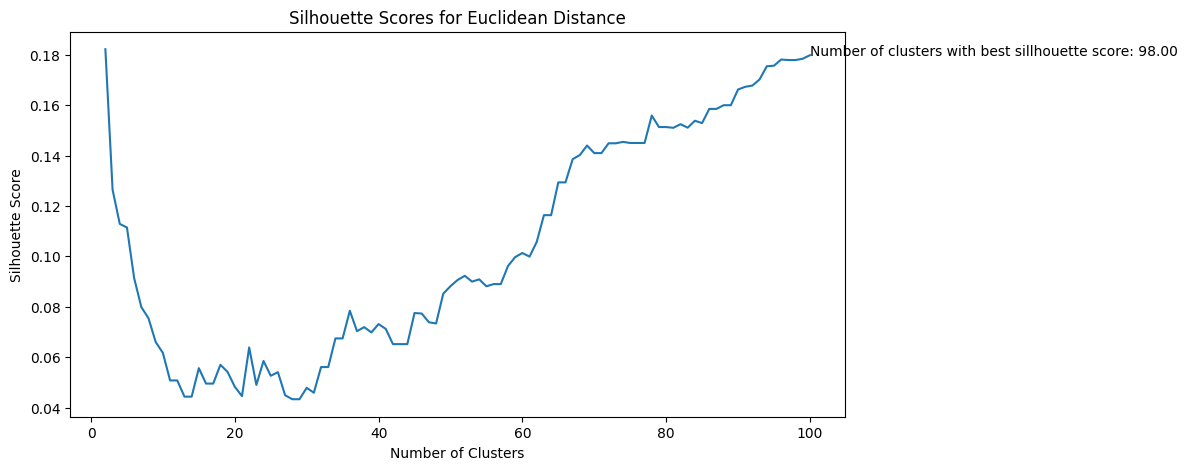

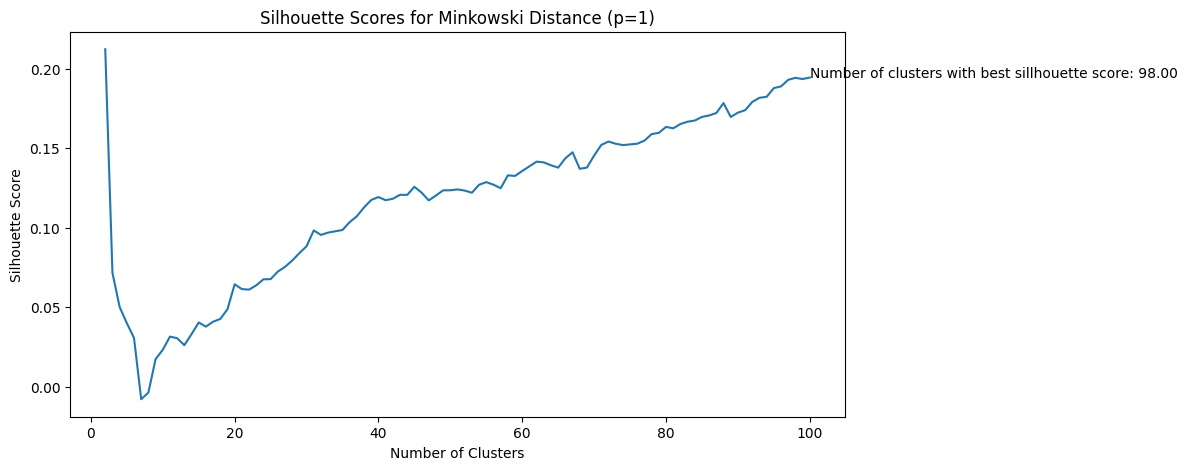

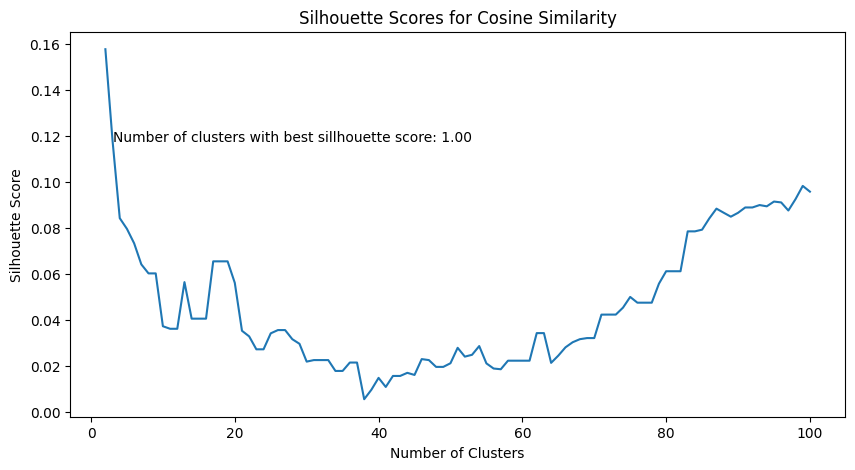

In [157]:
plot_silhouette_scores(euclidean_silhouette_scores, 'Silhouette Scores for Euclidean Distance')
plot_silhouette_scores(minkowski_silhouette_scores, 'Silhouette Scores for Minkowski Distance (p=1)')
plot_silhouette_scores(cosine_silhouette_scores, 'Silhouette Scores for Cosine Similarity')

In [162]:
# euclidean distance matrix as input
_, average_accuracy = evaluate_knn_with_pca(euclidean_distance_matrix, y_train)
print(f"Average accuracy with euclidean reduced dataset: {average_accuracy}")

# minkowski distance matrix as input
_, average_accuracy = evaluate_knn_with_pca(minkowski_distance_matrix, y_train)
print(f"Average accuracy with minkowski reduced dataset: {average_accuracy}")

# cosine distance matrix as input
_, average_accuracy = evaluate_knn_with_pca(cosine_distance_matrix, y_train)
print(f"Average accuracy with cosine reduced dataset: {average_accuracy}")


Average accuracy with euclidean reduced dataset: 0.5882352941176471
Average accuracy with minkowski reduced dataset: 0.7147058823529411
Average accuracy with cosine reduced dataset: 0.5441176470588236
